<center>

# Analysis of Single crystal output

### Author: Daniel Lomholt Christensen @nbi summer 2025

</center>

In [1]:
import numpy as np
import mcstasscript as ms
import matplotlib.pyplot as plt

In [2]:
data_single = ms.load_data('../data/single_crystal_ybco')
data_pretty_plot = ms.load_data('../data/single_crystal_high_wave')
data_ncrystal = ms.load_data('../data/ncrystal_ybco')
data_cop = ms.load_data('../data/single_crystal_cop')

In [3]:
# fourPiMon = data_single[-5]
# fourPiMon = data_cop[-5]
fourPiMon = data_pretty_plot[-5]
azim = (fourPiMon.metadata.limits[0],fourPiMon.metadata.limits[1])
vert = fourPiMon.metadata.limits[2],fourPiMon.metadata.limits[3]


X, Y = np.meshgrid(np.linspace(*azim, 3600), np.linspace(*vert,3600))

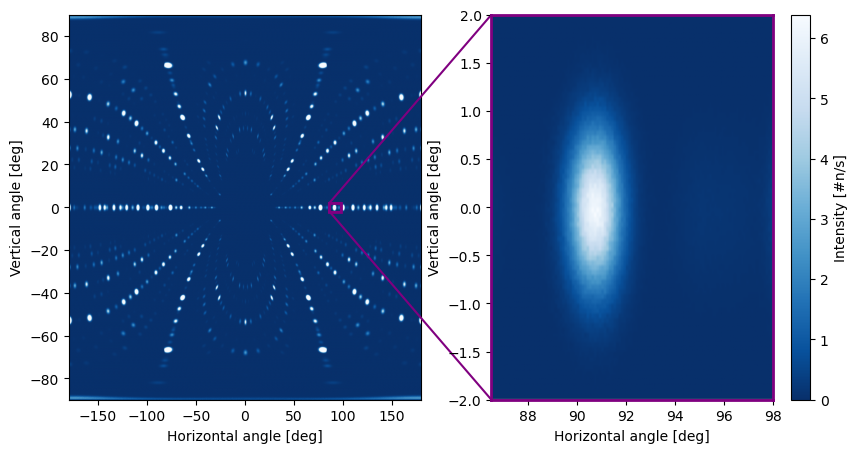

In [12]:
%matplotlib inline
# First plot the 4 Pi monitor
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
ax[0].imshow(fourPiMon.Intensity, norm='symlog', 
             cmap='Blues_r', vmin=0, vmax=0.5,
             extent =fourPiMon.metadata.limits, aspect='auto')
ax[0].set(xlabel='Horizontal angle [deg]', ylabel='Vertical angle [deg]')
ax[1].set(xlabel='Horizontal angle [deg]', ylabel='Vertical angle [deg]')
# Make a mask to select only the data that is within a specific reflection
x_min = 86.5
x_max = 98
y_min = -2
y_max = 2
mask = ((X>x_min) & (X<x_max))
mask = mask & ((Y>y_min) & (Y<y_max))
zoomed_in = np.where(mask, fourPiMon.Intensity, np.nan)   # same shape as X (3600, 3600)

heat = ax[1].imshow(zoomed_in, norm='linear',cmap='Blues_r', aspect='auto',
                    extent=fourPiMon.metadata.limits)
ax[1].set_xlim(x_min, x_max)   # zoom in x-range
ax[1].set_ylim(y_min, y_max)   # zoom in y-range
fig.colorbar(heat, label=r"Intensity [#n/s]")
# Make a 

# --- Add a zooming box on the left plot ---
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
rect = patches.Rectangle((x_min, y_min),   # lower left corner
                         x_max - x_min,    # width
                         y_max - y_min,    # height
                         linewidth=2, edgecolor='purple', facecolor='none')
ax[0].add_patch(rect)

# --- Draw connector lines between box and zoom subplot ---
mark_inset(ax[0], ax[1],
           loc1=2, loc2=3,   # corners to connect (2=upper left, 4=lower right)
           fc="none", ec="purple", lw=1.5)

# --- Add colored border around zoomed plot ---
for spine in ax[1].spines.values():
    spine.set_edgecolor("purple")
    spine.set_linewidth(2)

In [12]:
0.639048

0.639048

In [13]:
# Check that the given reflection is (220) and the extra one is (110), 
# used for looking up in .txt files containing the form factors.
d = 1.942/2/np.sin(90.9*np.pi/180/2)
print(d)
lam_ybco = 1.366456*2 * np.sin(90.8/2*np.pi/180)
print(f"Wavelength of ybco peak = {lam_ybco}")
lam_cop = 2*1.278096*np.sin(94/2*np.pi/180)
d_cop = 1.873/2/np.sin(94/2*np.pi/180)
# lam_cop = 2*1.807500*np.sin(94/2*np.pi/180)
print(f"Wavelength of Copper peak = {lam_cop:.4g}\tD spacing of copper peak = {d_cop:.4g}")

1.3625421222872611
Wavelength of ybco peak = 1.9459045254013458
Wavelength of Copper peak = 1.869	D spacing of copper peak = 1.281


In [15]:
# Find the integral of the reflection
def calculate_intensity(
        vol, unit_cell, specific_flux, 
        wavelength_band, wavelength, 
        theta, form_factor)->float:
    return vol/unit_cell**2 * specific_flux/wavelength_band * wavelength**4/(2*np.sin(theta)**2) * form_factor

zoomed_in = np.where(mask, data_single[-5].Intensity, np.nan)   # same shape as X (3600, 3600)

simul_result_ybco = np.sum(zoomed_in[zoomed_in>0])
specific_flux_ybco = data_single[0].metadata.total_I # #n/s /cm^2
vol_ybco = 0.01 # cm^3

unit_cell_ybco = 404.778 # AA^3
wavelength_ybco = 1.944 # AA
wavelength_band_ybco = 0.4 ## AA
theta_ybco = 90.8*np.pi/180/2 # Half of the angle measured
form_factor_ybco = 105.588**2/100
# form_factor_ybco = 166.405633**2/100 # fm to barns
anal_ybco: float = calculate_intensity(vol_ybco, unit_cell_ybco,
                                        specific_flux_ybco, wavelength_band_ybco, 
                                        wavelength_ybco, theta_ybco, form_factor_ybco)


zoomed_in_ncrystal = np.where(mask, data_ncrystal[-5].Intensity, np.nan)   # same shape as X (3600, 3600)

simul_result_ybco_ncrystal = np.sum(zoomed_in_ncrystal[zoomed_in_ncrystal>0])

print(f"YBCO Analytical result = {anal_ybco:.4f}\tSimulation result = {simul_result_ybco:.4f}"
      f"\tncrystal={simul_result_ybco_ncrystal:.4f}"
      )
print(f"difference={(anal_ybco-simul_result_ybco)/anal_ybco}")

######################### COPPER SECTION


zoomed_in = np.where(mask, data_cop[-6].Intensity, np.nan)   # same shape as X (3600, 3600)
simul_result_cop = np.sum(zoomed_in[zoomed_in>0])

vol_cop = 0.01 # cm^3
specific_flux_cop = data_cop[0].metadata.total_I # #n/s /cm^2
unit_cell_cop = 47.2416
wavelength_cop = 1.8694804812493104
wavelength_band_cop = 0.2
theta_cop = 94*np.pi/180/2 # Half of the angle measured
form_factor_cop = 30.872


form_factor_cop = form_factor_cop**2/100 # Convert fm^2 to barns 
# form_factor_cop = 9.5308

anal_cop: float = calculate_intensity(vol_cop, unit_cell_cop, specific_flux_cop, 
                                      wavelength_band_cop, wavelength_cop, 
                                      theta_cop, form_factor_cop)


print(f"Copper Analytical result = {anal_cop:.4f}\tSimulation result = {simul_result_cop:.4f}")
# print(anal_cop,vol, unit_cell, specific_flux, wavelength_band, wavelength, theta, form_fact)
print(f"difference={(anal_cop-simul_result_cop)/anal_cop}")

YBCO Analytical result = 8.7360	Simulation result = 8.4903	ncrystal=8.4194
difference=0.0281227515688906
Copper Analytical result = 55.2853	Simulation result = 7.5776
difference=0.8629359635421255


In [16]:
form_factor_cop

9.530803839999999

In [ ]:
# Load all reflections from the file
import pandas as pd
colnames = ["h", "k", "l", "d_A", "F_real", "F_imag", "F_abs", "two_theta", "I", "M"]
reflections = pd.read_table("YBaCuO.txt",
                            sep=r'\s+',   # handle variable spacing
                            comment="#", names=colnames, skiprows=1,
                            engine="python")         # safer for whitespace parsing)
reflections['F2'] = np.array(reflections['F_abs'])**2*np.array(reflections['M'])

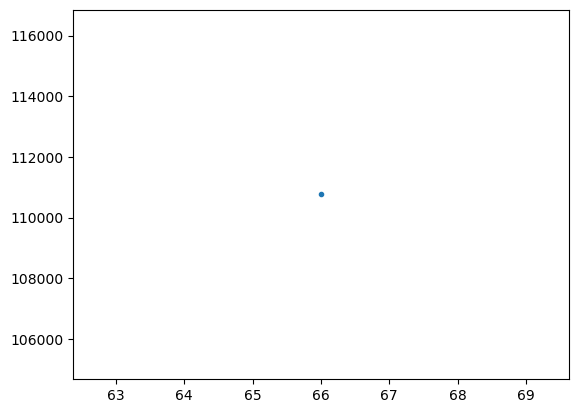

In [ ]:
fig, ax = plt.subplots()
ax.plot(reflections['F2'][reflections['F2']>100000], '.')

In [ ]:
# print(anal_ybco, vol_ybco, specific_flux_ybco, wavelength_band_ybco, wavelength_ybco,
#       theta_ybco, form_factor_ybco)

In [ ]:
# dat = []
# for i in range(21):
#     dat.append(ms.load_data('../data/single_crystal_scan/' + str(i))[-3])
# ms.make_sub_plot(dat)

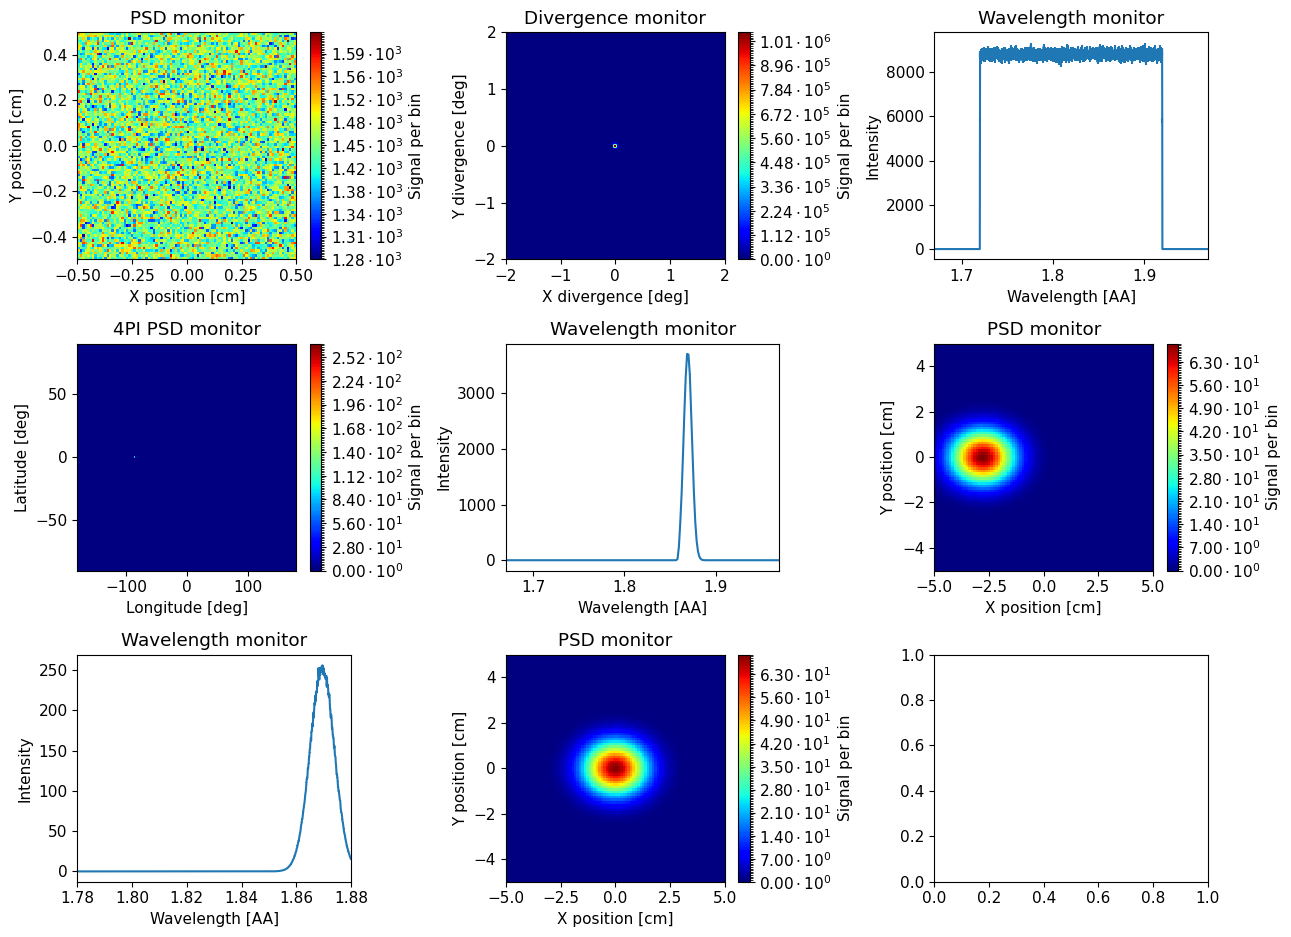

In [ ]:
ms.make_sub_plot(data_cop)

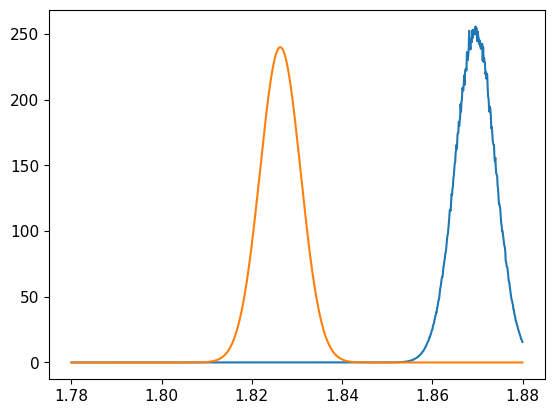

In [ ]:
def gauss(x,sig,x0, A):
    return A*np.exp(-(x-x0)**2/2/sig**2)

fig, ax = plt.subplots()
x = data_cop[-2].xaxis
ax.plot(data_cop[-2].xaxis, data_cop[-2].Intensity)
ax.plot(data_cop[-2].xaxis, gauss(data_cop[-2].xaxis, 0.0045, 1.8263, 240))

In [ ]:
0.333*np.pi/180

0.005811946409141117